### Подключаем необходимые библиотеки, фреймворки, набор данных, а также изменим вывод данных для удобного просмотра информации

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st
from sklearn.model_selection import train_test_split

pd.options.display.max_columns = None
pd.set_option('display.float_format', '{:.2f}'.format)

df=pd.read_csv('diabetes.csv')

### Просмотрим набор и оценим проблемы в данных:

#### Проведем первичный анализ данных:

In [80]:
display(df.info())

columss=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

for i in columss:
    print(f'Описания признака {i}:')
    print(df[i].describe())
    print()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

Описания признака Pregnancies:
count   768.00
mean      3.85
std       3.37
min       0.00
25%       1.00
50%       3.00
75%       6.00
max      17.00
Name: Pregnancies, dtype: float64

Описания признака Glucose:
count   768.00
mean    120.89
std      31.97
min       0.00
25%      99.00
50%     117.00
75%     140.25
max     199.00
Name: Glucose, dtype: float64

Описания признака BloodPressure:
count   768.00
mean     69.11
std      19.36
min       0.00
25%      62.00
50%      72.00
75%      80.00
max     122.00
Name: BloodPressure, dtype: float64

Описания признака SkinThickness:
count   768.00
mean     20.54
std      15.95
min       0.00
25%       0.00
50%      23.00
75%      32.00
max      99.00
Name: SkinThickness, dtype: float64

Описания признака Insulin:
count   768.00
mean     79.80
std     115.24
min       0.00
25%       0.00
50%      30.50
75%     127.25
max     846.00
Name: Insulin, dtype: float64

Описания признака BMI:
count   768.00
mean     31.99
std       7.88
min       

Рассмотрим подробнее класс Outcome (целевая переменная - показатель наличия/отсутствия диабета):

In [81]:
display(df['Outcome'].value_counts()/len(df)*100)

Outcome
0   65.10
1   34.90
Name: count, dtype: float64

Наблюдаем диспропорцию классов: 
* Класс 0 (здоровые) - 65.1% наблюдений
* Класс 1 (больные) - 34.9% наблюдений

На данном этапе был проведён первичный анализ структуры данных и целевой переменной, что позволило выявить дисбаланс классов и потенциальные проблемы качества данных.

#### Анализ некорректных значений

Рассмотрим выбросы класса Glucose(переменная - показатель уровня глюкозы в крови мг/дл):

In [82]:
bad_arr=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for i in bad_arr:
    print(f'Признак - {i}:',len(df[(df[i]==0)]),len(df[(df[i]==0)])/len(df)*100,sep='\n')

    print(f'Среди них из класса 0 - здоровые:',len(df[(df[i]==0)&(df['Outcome']==0)]),len(df[(df[i]==0)&(df['Outcome']==0)])/len(df[(df[i]==0)])*100,sep='\n')

    print(f'Среди них из класса 1 - больные:',len(df[(df[i]==0)&(df['Outcome']==1)]),len(df[(df[i]==0)&(df['Outcome']==1)])/len(df[(df[i]==0)])*100,sep='\n')

    display(df[(df[i]==0)].head())

    print()

Признак - Glucose:
5
0.6510416666666667
Среди них из класса 0 - здоровые:
3
60.0
Среди них из класса 1 - больные:
2
40.0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
75,1,0,48,20,0,24.70,0.14,22,0
182,1,0,74,20,23,27.70,0.30,21,0
342,1,0,68,35,0,32.00,0.39,22,0
349,5,0,80,32,0,41.00,0.35,37,1
502,6,0,68,41,0,39.00,0.73,41,1



Признак - BloodPressure:
35
4.557291666666666
Среди них из класса 0 - здоровые:
19
54.285714285714285
Среди них из класса 1 - больные:
16
45.714285714285715


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
7,10,115,0,0,0,35.30,0.13,29,0
15,7,100,0,0,0,30.00,0.48,32,1
49,7,105,0,0,0,0.00,0.30,24,0
60,2,84,0,0,0,0.00,0.30,21,0
78,0,131,0,0,0,43.20,0.27,26,1



Признак - SkinThickness:
227
29.557291666666668
Среди них из класса 0 - здоровые:
139
61.23348017621145
Среди них из класса 1 - больные:
88
38.76651982378855


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2,8,183,64,0,0,23.30,0.67,32,1
5,5,116,74,0,0,25.60,0.20,30,0
7,10,115,0,0,0,35.30,0.13,29,0
9,8,125,96,0,0,0.00,0.23,54,1
10,4,110,92,0,0,37.60,0.19,30,0



Признак - Insulin:
374
48.69791666666667
Среди них из класса 0 - здоровые:
236
63.101604278074866
Среди них из класса 1 - больные:
138
36.898395721925134


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
5,5,116,74,0,0,25.60,0.20,30,0
7,10,115,0,0,0,35.30,0.13,29,0



Признак - BMI:
11
1.4322916666666665
Среди них из класса 0 - здоровые:
9
81.81818181818183
Среди них из класса 1 - больные:
2
18.181818181818183


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
9,8,125,96,0,0,0.00,0.23,54,1
49,7,105,0,0,0,0.00,0.30,24,0
60,2,84,0,0,0,0.00,0.30,21,0
81,2,74,0,0,0,0.00,0.10,22,0
145,0,102,75,23,0,0.00,0.57,21,0


Всего нулевых значений - 5 штук (доля 0.65). Это явно некорректные значения (минимальный возможный уровень глюкозы = 27 мг/дл). Вероятнее всего эти значения - пропущенные данные, что просто решили закодировать нулями.

Рассмотрим выбросы класса BloodPressure (переменная - показатель артериального давления мм. рт. ст.):

Всего нулевых значений в BloodPressure - 35 (доля 4.56%). Это явно некорректные значения (минимальное возможное давление = 60 мм. рт. ст.). Заметим также, что когда отсутвуют значения в BloodPressure, также отсутствуют значения и в SkinThickness и в Insulin. Это явный признак того, что значения в этих наблюдениях являются пропущеными и просто закодированы нулями.

Рассмотрим выбросы класса SkinThickness (переменная - показатель толщины кожной складки трицепса мм):

Всего нулевых значений в SkinThickness - 227 (доля 29.56%). Это явно некорректные значения (толщина кожы не может быть = 0 мм). Заметим также, что когда отсутвуют значения в SkinThickness, также отсутствуют значения и в Insulin. Это явный признак того, что значения в этих наблюдениях являются пропущеными и просто закодированы нулями.

Рассмотрим выбросы класса Insulin (переменная - показатель кол-ва инсулина натощак в мкЕд/мл):

Всего нулевых значений в Insulin - 374 (доля 48.7%). Это явно некорректные значения (инсулин не может быть нулевым). Вероятнее всего эти значения - пропущенные данные, что просто решили закодировать нулями.

Рассмотрим выбросы класса BMI (переменная - индекс массы тела кг/(м^2)):

Всего нулевых значений в BMI - 11 (доля 1.43%). Это явно некорректные значения (нулевойй значения ИМТ означает что вес пациента 0 кг). Заметим также, что в подавляющем числе наблюдений когда отсутвуют значения в BMI , также отсутствуют значения и в Insulin, и в SkinThickness и в BloodPressure. Это явный признак того, что значения в этих наблюдениях являются пропущеными и просто закодированы нулями.

### Предобработка данных

Проверим есть ли дубликаты:

In [83]:
display(df.duplicated().value_counts())

False    768
Name: count, dtype: int64

Полных дубликатов не обнаружилось, неполные дубликаты в этом датасете не определить.

Заменим некорректные нулевые значения на NaN:

In [84]:
bad_arr=['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for i in bad_arr:
    df.loc[df[i]==0,i]=np.nan

display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB


None

Разобъем данные на обучающую, валидационную и тестовую в отношении 70%/15%/15%. 

In [85]:
df_train,df_test=train_test_split(df,test_size=0.3,random_state=12345)

df_test,df_val=train_test_split(df_test,test_size=0.5,random_state=12345)

display(len(df_train),len(df_val),len(df_test))

537

116

115

Чтобы избежать утечки данных обучим предобработку данных только на обучающей выборке, а затем применим преобразования и к валидационной и тестовой выборке.

Используем медианную импутацию отдельно для каждого класса (Outcome=0 и Outcome=1) чтобы восстановить недостающие данные.

In [86]:
print('Train')
display(df_train[bad_arr].info(),df_train[bad_arr].describe())

print('Val')
display(df_val[bad_arr].info(),df_val[bad_arr].describe())

print('Test')
display(df_test[bad_arr].info(),df_test[bad_arr].describe())

Train
<class 'pandas.DataFrame'>
Index: 537 entries, 48 to 482
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose        535 non-null    float64
 1   BloodPressure  514 non-null    float64
 2   SkinThickness  374 non-null    float64
 3   Insulin        270 non-null    float64
 4   BMI            528 non-null    float64
dtypes: float64(5)
memory usage: 25.2 KB


None

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,535.00,514.00,374.00,270.00,528.00
mean,123.43,72.82,29.11,153.23,32.57
std,30.54,12.42,10.53,118.91,7.11
min,56.00,30.00,7.00,14.00,18.20
25%,101.50,64.00,22.00,76.25,27.40
50%,119.00,72.00,29.00,125.50,32.40
75%,143.00,80.00,36.00,185.00,36.80
max,199.00,114.00,99.00,846.00,67.10


Val
<class 'pandas.DataFrame'>
Index: 116 entries, 479 to 606
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose        113 non-null    float64
 1   BloodPressure  106 non-null    float64
 2   SkinThickness  80 non-null     float64
 3   Insulin        62 non-null     float64
 4   BMI            114 non-null    float64
dtypes: float64(5)
memory usage: 5.4 KB


None

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,113.00,106.00,80.00,62.00,114.00
mean,118.63,71.80,30.21,162.00,32.67
std,30.30,12.37,10.03,111.99,6.21
min,44.00,24.00,8.00,25.00,19.60
25%,95.00,64.25,20.00,82.25,28.32
50%,112.00,72.00,32.00,124.00,32.60
75%,140.00,80.00,37.25,207.50,37.05
max,196.00,106.00,51.00,495.00,49.70


Test
<class 'pandas.DataFrame'>
Index: 115 entries, 258 to 471
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose        115 non-null    float64
 1   BloodPressure  113 non-null    float64
 2   SkinThickness  87 non-null     float64
 3   Insulin        62 non-null     float64
 4   BMI            115 non-null    float64
dtypes: float64(5)
memory usage: 5.4 KB


None

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,115.00,113.00,87.00,62.00,115.00
mean,116.57,71.08,28.34,159.18,31.74
std,30.21,12.23,10.66,126.17,6.76
min,65.00,40.00,7.00,16.00,18.20
25%,95.00,64.00,19.50,75.50,27.30
50%,111.00,70.00,27.00,122.50,31.20
75%,129.00,78.00,35.00,183.50,35.25
max,197.00,122.00,60.00,600.00,57.30


In [87]:
arr_of_median_0 = []
arr_of_median_1 = []

for col in bad_arr:
    median_0 = df_train.loc[df_train['Outcome'] == 0, col].median()
    median_1 = df_train.loc[df_train['Outcome'] == 1, col].median()
    
    arr_of_median_0.append(median_0)
    arr_of_median_1.append(median_1)


def fill_by_class(df_part, bad_arr, med0, med1):
    df_part = df_part.copy()
    
    for i, col in enumerate(bad_arr):
        df_part.loc[df_part['Outcome'] == 0, col] = \
            df_part.loc[df_part['Outcome'] == 0, col].fillna(med0[i])
        
        df_part.loc[df_part['Outcome'] == 1, col] = \
            df_part.loc[df_part['Outcome'] == 1, col].fillna(med1[i])
    
    return df_part


arr_of_median_0 = []
arr_of_median_1 = []

for col in bad_arr:
    median_0 = df_train.loc[df_train['Outcome'] == 0, col].median()
    median_1 = df_train.loc[df_train['Outcome'] == 1, col].median()
    
    arr_of_median_0.append(median_0)
    arr_of_median_1.append(median_1)

df_train = fill_by_class(df_train, bad_arr, arr_of_median_0, arr_of_median_1)
df_val   = fill_by_class(df_val,   bad_arr, arr_of_median_0, arr_of_median_1)
df_test  = fill_by_class(df_test,  bad_arr, arr_of_median_0, arr_of_median_1)

In [88]:
print('Train')
display(df_train[bad_arr].info(),df_train[bad_arr].describe())

print('Val')
display(df_val[bad_arr].info(),df_val[bad_arr].describe())

print('Test')
display(df_test[bad_arr].info(),df_test[bad_arr].describe())

Train
<class 'pandas.DataFrame'>
Index: 537 entries, 48 to 482
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose        537 non-null    float64
 1   BloodPressure  537 non-null    float64
 2   SkinThickness  537 non-null    float64
 3   Insulin        537 non-null    float64
 4   BMI            537 non-null    float64
dtypes: float64(5)
memory usage: 25.2 KB


None

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,537.00,537.00,537.00,537.00,537.00
mean,123.43,72.79,29.09,140.11,32.54
std,30.49,12.16,8.89,87.33,7.05
min,56.00,30.00,7.00,14.00,18.20
25%,102.00,64.00,25.00,105.00,27.50
50%,119.00,72.00,28.00,105.00,32.40
75%,143.00,80.00,32.00,159.50,36.60
max,199.00,114.00,99.00,846.00,67.10


Val
<class 'pandas.DataFrame'>
Index: 116 entries, 479 to 606
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose        116 non-null    float64
 1   BloodPressure  116 non-null    float64
 2   SkinThickness  116 non-null    float64
 3   Insulin        116 non-null    float64
 4   BMI            116 non-null    float64
dtypes: float64(5)
memory usage: 5.4 KB


None

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,116.00,116.00,116.00,116.00,116.00
mean,118.64,71.82,29.73,143.45,32.63
std,29.99,11.84,8.45,85.74,6.17
min,44.00,24.00,8.00,25.00,19.60
25%,96.50,66.00,27.00,105.00,28.38
50%,111.00,72.00,29.50,105.00,32.30
75%,139.25,78.00,35.00,159.50,36.75
max,196.00,106.00,51.00,495.00,49.70


Test
<class 'pandas.DataFrame'>
Index: 115 entries, 258 to 471
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Glucose        115 non-null    float64
 1   BloodPressure  115 non-null    float64
 2   SkinThickness  115 non-null    float64
 3   Insulin        115 non-null    float64
 4   BMI            115 non-null    float64
dtypes: float64(5)
memory usage: 5.4 KB


None

,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,115.00,115.00,115.00,115.00,115.00
mean,116.57,71.15,28.45,140.84,31.74
std,30.21,12.13,9.34,95.83,6.76
min,65.00,40.00,7.00,16.00,18.20
25%,95.00,64.00,23.50,105.00,27.30
50%,111.00,70.00,27.00,105.00,31.20
75%,129.00,78.00,32.00,159.50,35.25
max,197.00,122.00,60.00,600.00,57.30


Импутация проводилась раздельно для каждой группы, что позволило сохранить различия в распределениях признаков между здоровыми и больными.

### Обнаружение и обработка выбросов

Опрделим границы выбросов:

In [89]:
num_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
            'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Q1 = df_train[num_cols].quantile(0.25)
Q3 = df_train[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_vybros = pd.DataFrame({
    'Q1': Q1,
    'Q3': Q3,
    'IQR': IQR,
    'Lower': lower_bound,
    'Upper': upper_bound
})

display(df_vybros)



,Q1,Q3,IQR,Lower,Upper
Pregnancies,1.00,6.00,5.00,-6.50,13.50
Glucose,102.00,143.00,41.00,40.50,204.50
BloodPressure,64.00,80.00,16.00,40.00,104.00
SkinThickness,25.00,32.00,7.00,14.50,42.50
Insulin,105.00,159.50,54.50,23.25,241.25
BMI,27.50,36.60,9.10,13.85,50.25
DiabetesPedigreeFunction,0.24,0.59,0.34,-0.27,1.10
Age,24.00,41.00,17.00,-1.50,66.50


Определим кол-во значений за границами нормы:

In [90]:
def count_outliers(df_part, lower, upper):
    for col in lower.index:
        count = ((df_part[col] < lower[col]) | (df_part[col] > upper[col])).sum()
        print(f"{col}: {count} выбросов")

print("TRAIN:")
count_outliers(df_train, lower_bound, upper_bound)

print("\nVAL:")
count_outliers(df_val, lower_bound, upper_bound)

print("\nTEST:")
count_outliers(df_test, lower_bound, upper_bound)

TRAIN:
Pregnancies: 3 выбросов
Glucose: 0 выбросов
BloodPressure: 11 выбросов
SkinThickness: 61 выбросов
Insulin: 45 выбросов
BMI: 7 выбросов
DiabetesPedigreeFunction: 27 выбросов
Age: 6 выбросов

VAL:
Pregnancies: 0 выбросов
Glucose: 0 выбросов
BloodPressure: 2 выбросов
SkinThickness: 11 выбросов
Insulin: 11 выбросов
BMI: 0 выбросов
DiabetesPedigreeFunction: 9 выбросов
Age: 3 выбросов

TEST:
Pregnancies: 1 выбросов
Glucose: 0 выбросов
BloodPressure: 1 выбросов
SkinThickness: 15 выбросов
Insulin: 11 выбросов
BMI: 1 выбросов
DiabetesPedigreeFunction: 6 выбросов
Age: 0 выбросов


В результате анализа межквартильного размаха было выявлено 87 наблюдений (≈11.3% выборки), содержащих хотя бы одно статистически аномальное значение. При этом аномальные значения преимущественно приходятся на признаки Insulin, SkinThickness и DiabetesPedigreeFunction. Данные наблюдения не рассматривались как ошибки измерения и были сохранены в датасете для дальнейшего анализа.

Для снижения влияния экстремальмых значений была применена винзоризация: для отдельных количественных признаков значения за пределами 5-го и 95-го перцентилей заменялись соответствующими пороговыми значениями. Данный подход позволяет сохранить все наблюдения в выборке, одновременно ограничивая влияние редких экстремальных значений на процесс обучения моделей. 

Ограничим следующие признаки:
* Insulin
* SkinThickness
* DiabetesPedigreeFunction
* BMI

Не будем трогать:
* Age
* Pregnancies
* BloodPressure

In [91]:
def handle_outliers_selected(df_part, lower, upper):
    df_part = df_part.copy()
    
    for col in lower.index:
        df_part[col] = df_part[col].clip(lower=lower[col], upper=upper[col])
    
    return df_part

df_train = handle_outliers_selected(df_train, lower_bound, upper_bound)
df_val   = handle_outliers_selected(df_val,   lower_bound, upper_bound)
df_test  = handle_outliers_selected(df_test,  lower_bound, upper_bound)

### Разведочный анализ данных

Общие гистограммы для каждого числового признака:

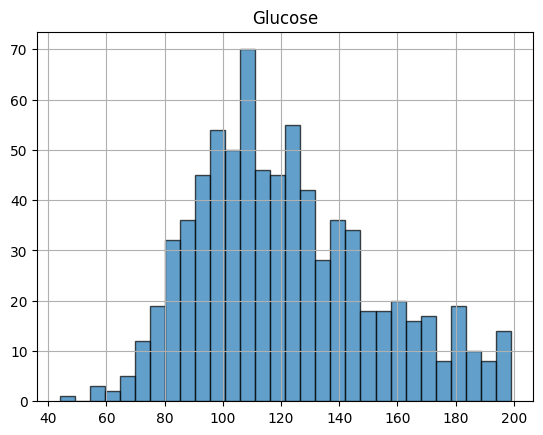

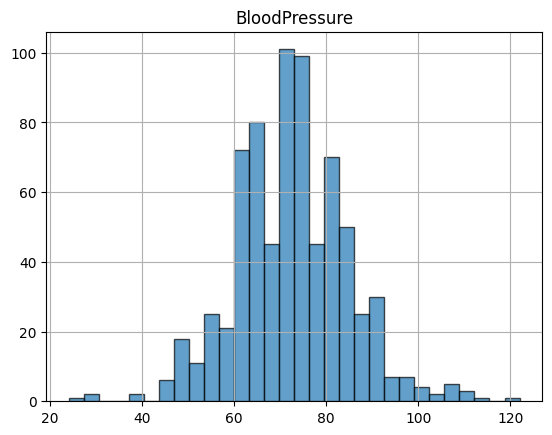

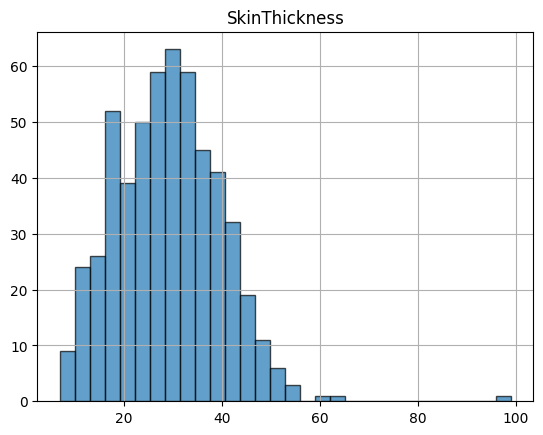

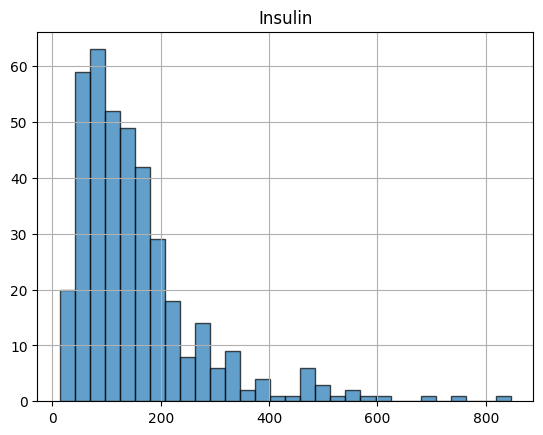

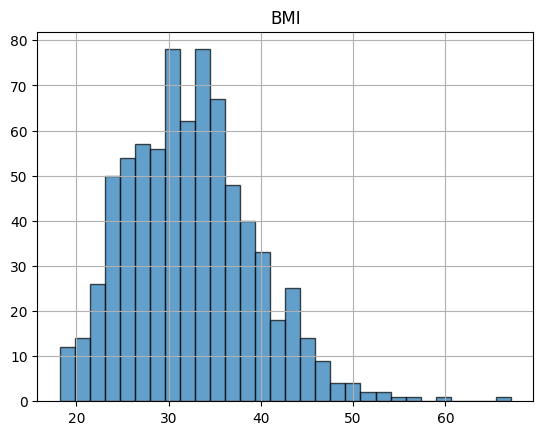

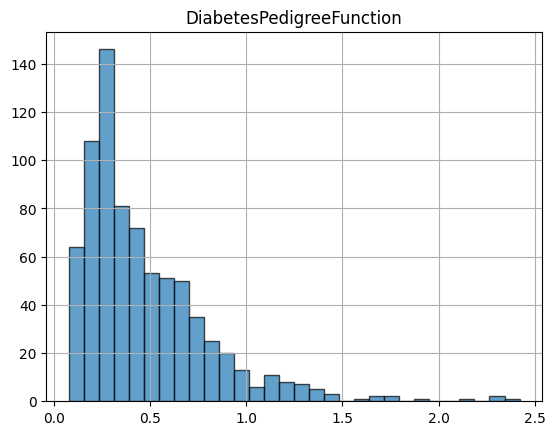

In [92]:
for i in df_train.columns[1:len(df.columns)-2]:
    df[i].hist(bins=30,alpha=0.7,edgecolor='black')
    plt.title(i)
    plt.show()

#### Построим гистограммы отдельно для больных и здоровых:

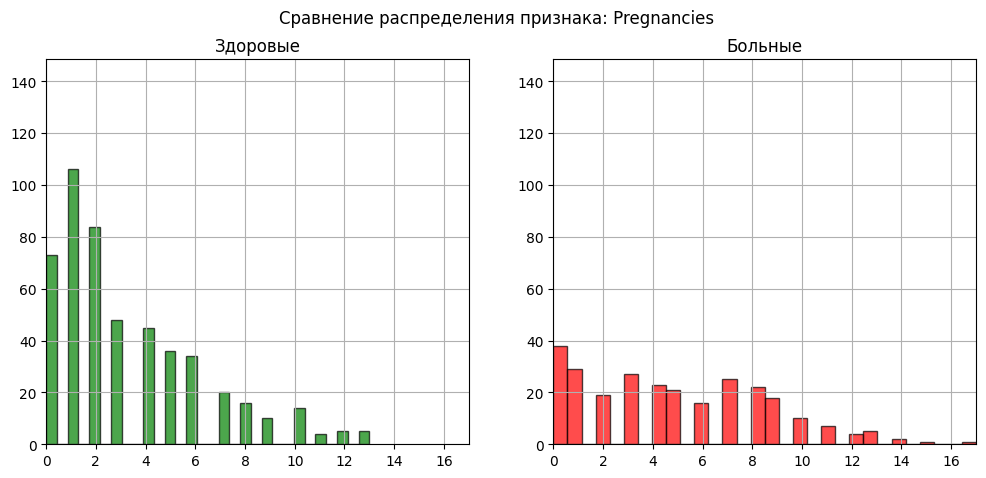

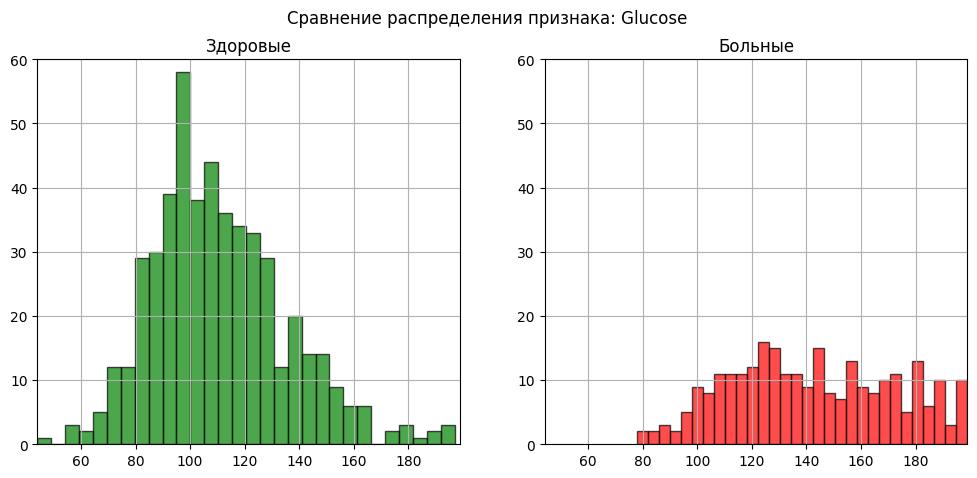

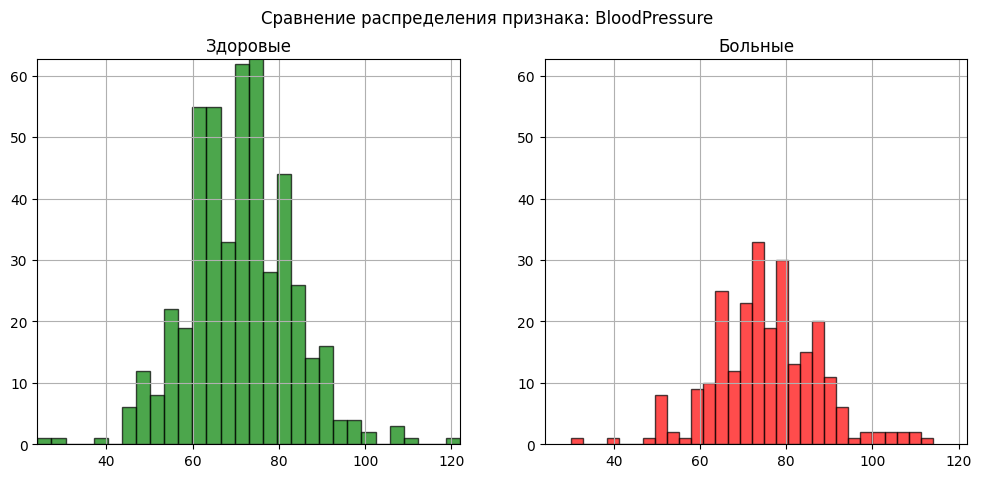

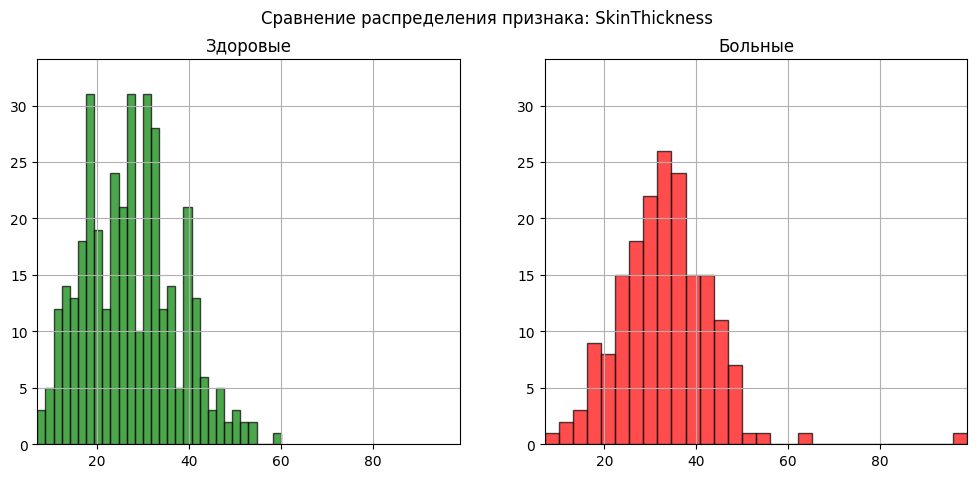

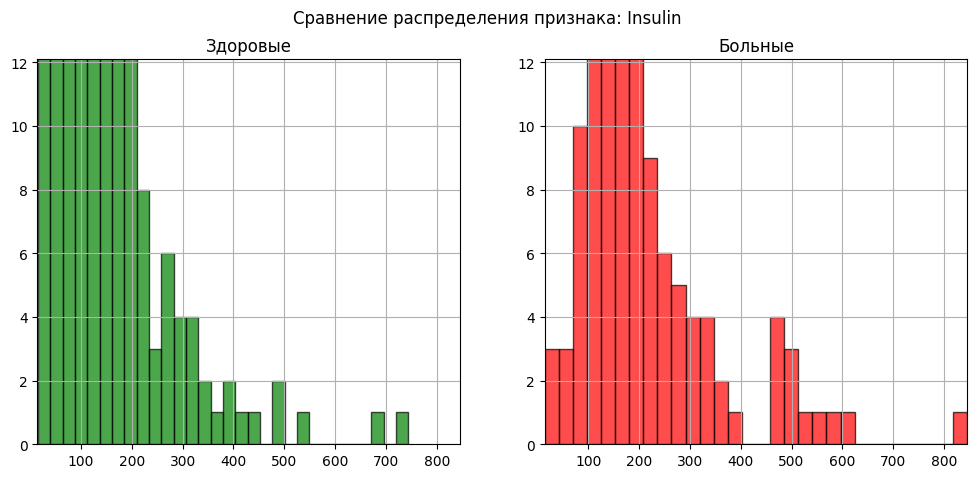

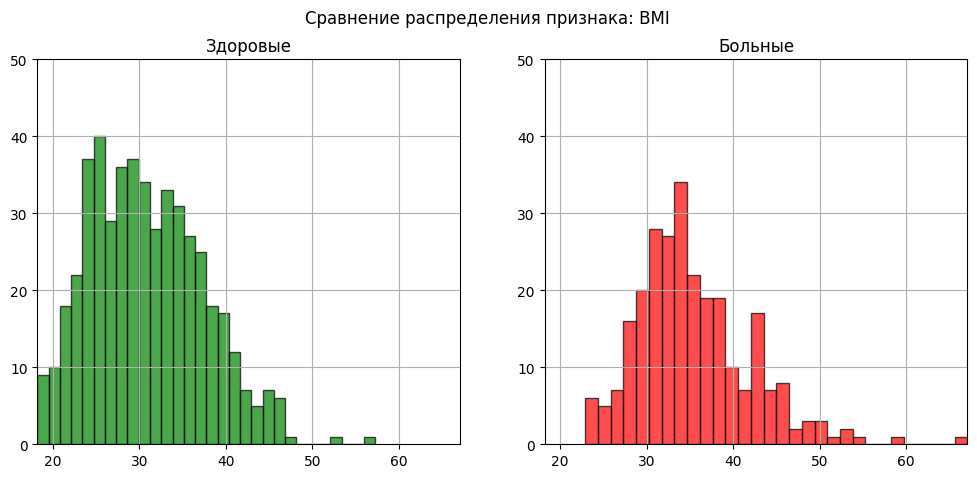

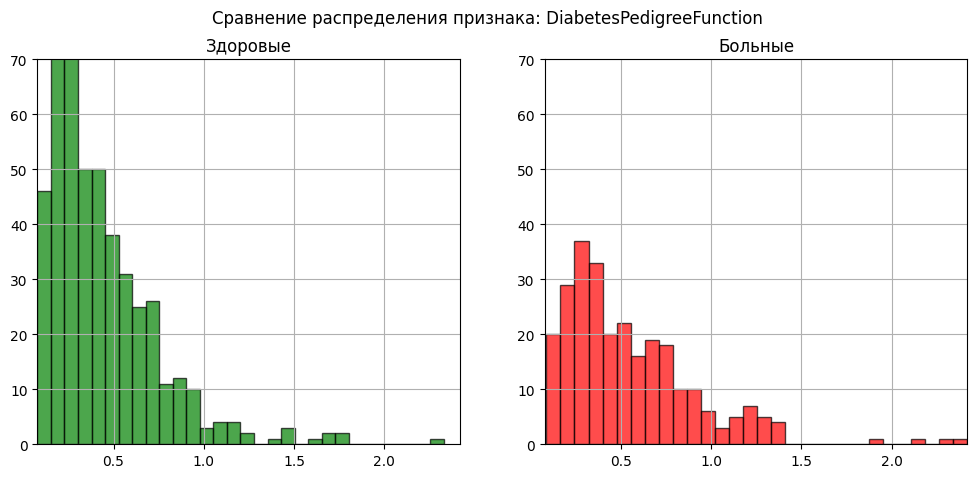

In [93]:
for i in df.columns[0:len(df.columns)-2]:

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    df.loc[df['Outcome'] == 0, i].hist(ax=ax1, bins=30, color='green', alpha=0.7, edgecolor='black')
    ax1.set_title('Здоровые')
    #ax1.set_xlabel(i)
    ax1.set_xlim(df[i].min(),df[i].max())
    ax1.set_ylim(0,(df[i].value_counts().max())*1.1)
    ax1.grid(True)
    
    df.loc[df['Outcome'] == 1, i].hist(ax=ax2, bins=30, color='red', alpha=0.7, edgecolor='black')
    ax2.set_title('Больные')
    #ax2.set_xlabel(i)
    ax2.set_xlim(df[i].min(),df[i].max())
    ax2.set_ylim(0,(df[i].value_counts().max())*1.1)
    ax2.grid(True)

    if i=='Glucose':
        ax1.set_ylim(0,60)
        ax2.set_ylim(0,60)
    
    if i=='BMI':
        ax1.set_ylim(0,50)
        ax2.set_ylim(0,50)
    
    if i=='DiabetesPedigreeFunction':
        ax1.set_ylim(0,70)
        ax2.set_ylim(0,70)
    if i=='Age':
        ax1.set_ylim(0,120)
        ax2.set_ylim(0,120)
    
    plt.suptitle(f'Сравнение распределения признака: {i}')
    
    plt.show()

Общие выводы:

* В ходе анализа распределений числовых признаков было установлено, что большинство переменных (Glucose, Insulin, BMI, SkinThickness) имеют асимметричные распределения с правосторонним смещением, что указывает на наличие выбросов и отклонение от нормального распределения.

* Распределения признаков Age и Pregnancies являются дискретными и скошенными (вправо), что обусловлено их природой и ограниченным диапазоном возможных значений.


Заметно, что такие признаки как 'SkinThickness' и 'Insulin' имеют хорошо выраженные центральные тенденции между группами здоровых и больных сахарным диабетом 2 типа:
* У пациентов с диабетом медианное значение толщины кожной складки смещено в сторону более высоких значений по сравнению с контрольной группой.
* Распределение признака Insulin демонстрирует заметное смещение медианного значения у пациентов с сахарным диабетом 2 типа в сторону более высоких значений.

Наложим гистограммы друг на друга для лучшего пониания:

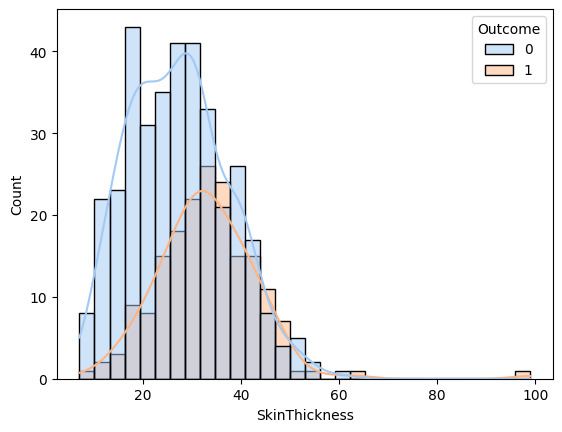

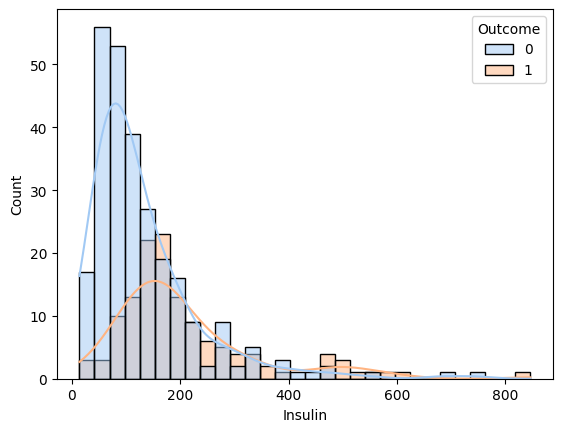

In [94]:
import seaborn as sns

for i in ['SkinThickness', 'Insulin']:
    sns.histplot(data=df, x=i, hue='Outcome', bins=30, kde=True, palette='pastel')
    plt.show()


Построим ящики с усами отдельно для больных и здоровых:

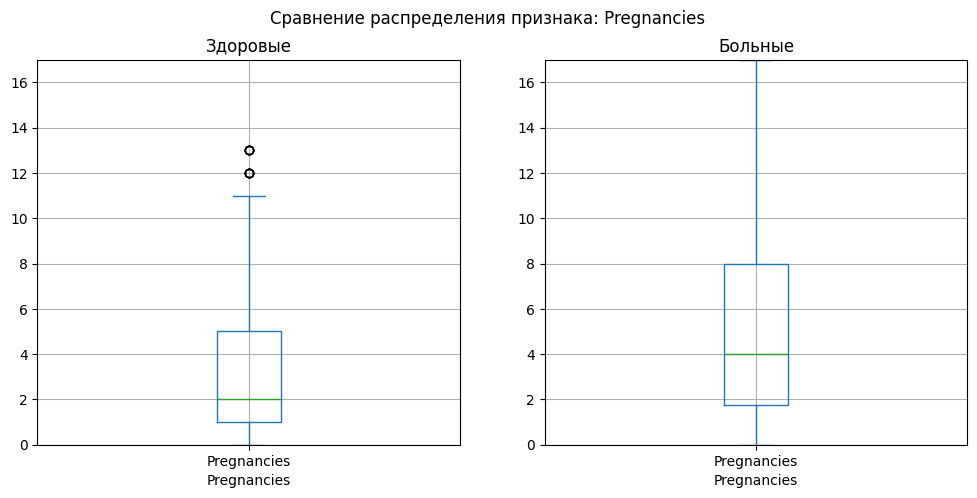

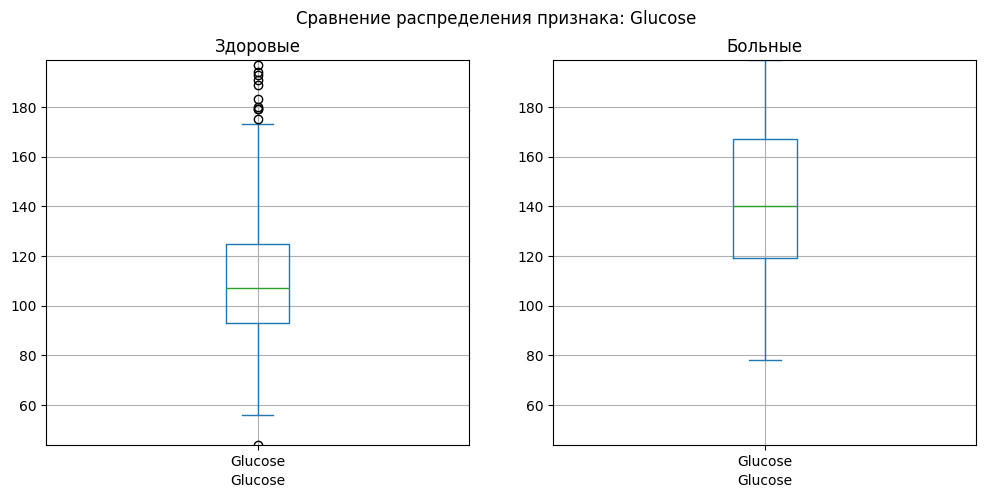

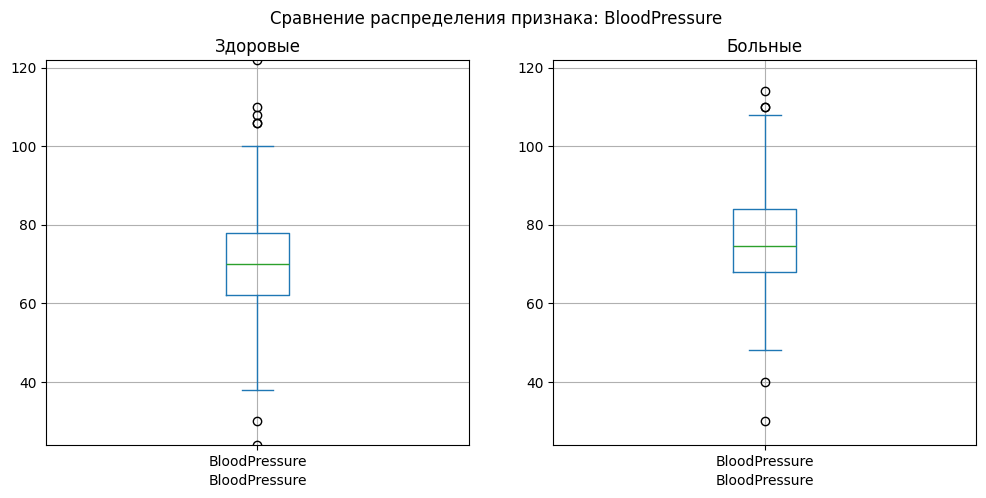

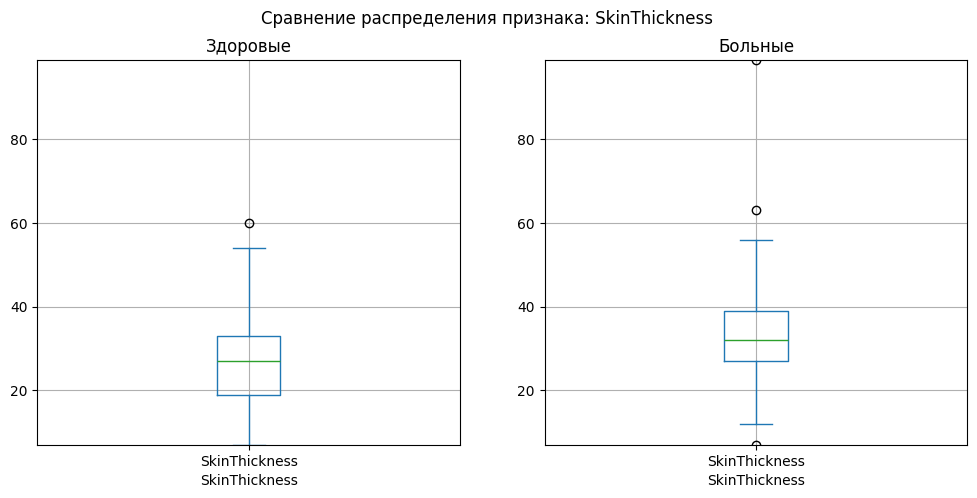

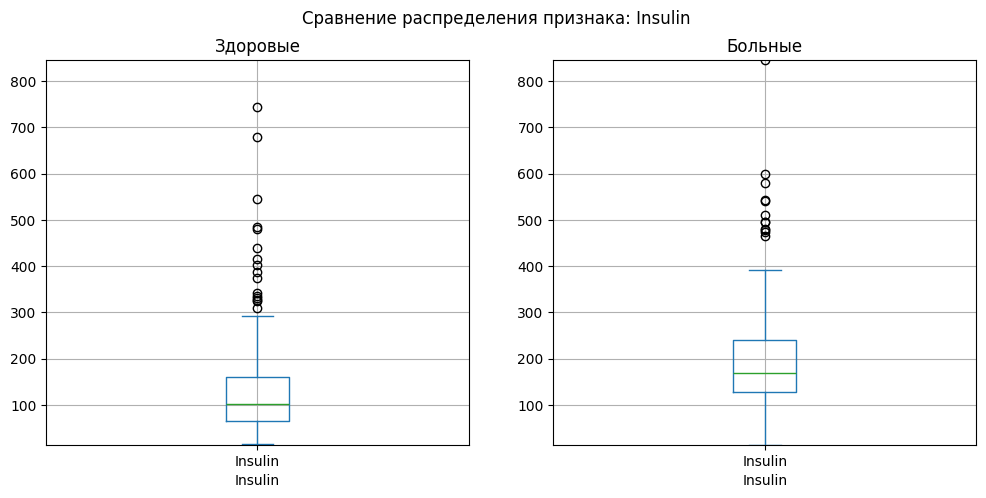

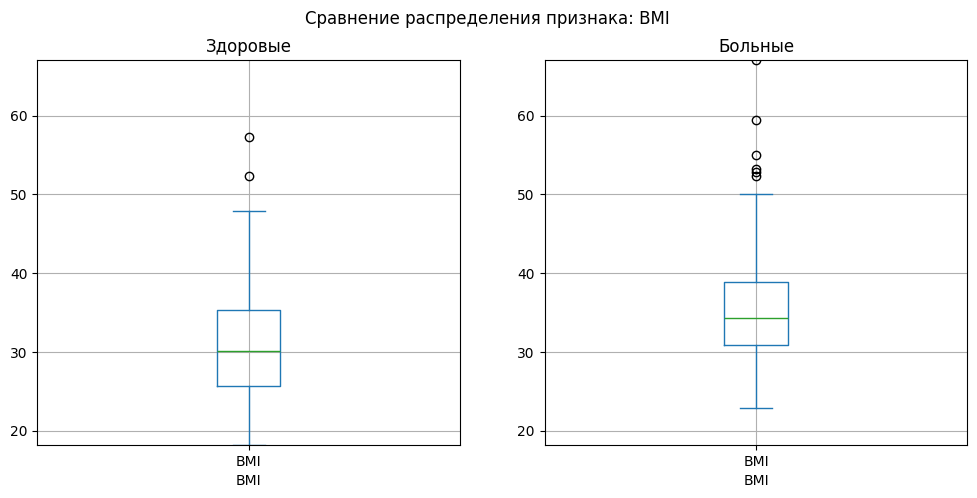

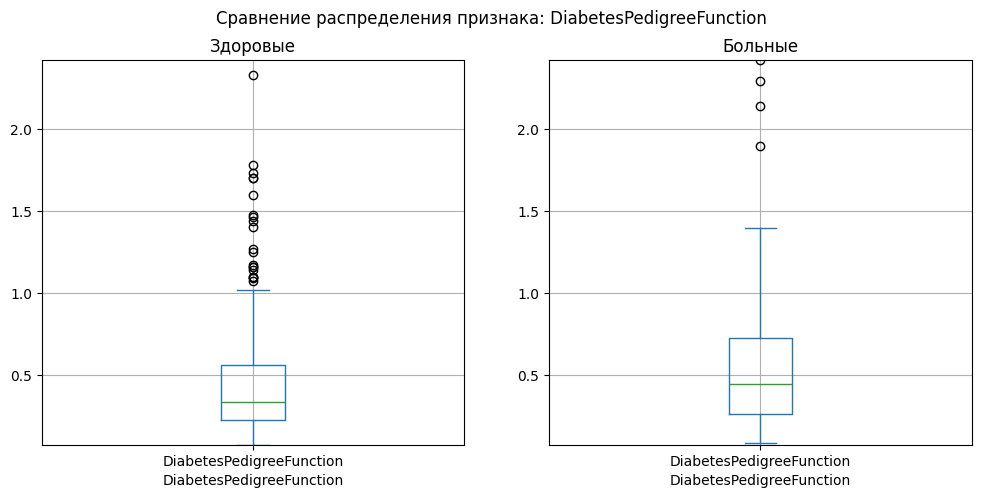

In [95]:
for i in df.columns[0:len(df.columns)-2]:

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    df.loc[df['Outcome'] == 0, i].plot(kind='box',ax=ax1)
    ax1.set_title('Здоровые')
    ax1.set_xlabel(i)
    ax1.grid(True)
    ax1.set_ylim(df[i].min(),df[i].max())

    df.loc[df['Outcome'] == 1, i].plot(kind='box',ax=ax2)
    ax2.set_title('Больные')
    ax2.set_xlabel(i)
    ax2.grid(True)
    ax2.set_ylim(df[i].min(),df[i].max())
    
    plt.suptitle(f'Сравнение распределения признака: {i}')
    
    plt.show()

Анализ boxplot показал различия медианных значениях у признаков между группами здоровых и больных сахарным диабетом 2 типа. Наиболее выраженные различия наблюдаются у признаков:
* Признак SkinThickness: 
    * Признак демонстрирует умеренное различие медианных значений между группами здоровых и больных.
    * Несмотря на более высокую медиану в группе больных, наблюдается существенное перекрытие межквартильных интервалов, а также наличие выбросов в обеих группах.
    * Это указывает на то, что признак SkinThickness обладает ограниченной индивидуальной предсказательной способностью и может быть информативен преимущественно в сочетании с другими признаками.
* Вывод по Pregnancies:
    * Распределение признака Pregnancies является дискретным и скошенным вправо, что обусловлено его природой. 
    * При сравнении по классам наблюдается тенденция к более высоким значениям данного признака у пациентов с сахарным диабетом 2 типа.
    * Вместе с тем распределения в группах существенно перекрываются, что указывает на ограниченную индивидуальную предсказательную способность признака.
* Вывод по Glucose:
    * Признак Glucose демонстрирует выраженные различия распределений между группами здоровых и больных.
    * У пациентов с сахарным диабетом медианное значение уровня глюкозы значительно выше, а распределение смещено в сторону больших значений.
    * Перекрытие распределений минимально по сравнению с другими признаками, что указывает на высокую дискриминативную способность данного показателя.
* Вывод по BloodPressure:
    * Распределение признака BloodPressure близко к симметричному, однако различия между группами выражены слабо.
    * Медианные значения и межквартильные размахи для здоровых и больных пациентов в значительной степени перекрываются.
    * Признак обладает низкой индивидуальной предсказательной способностью и, вероятно, играет вспомогательную роль в модели.
* Вывод по Insulin:
    * Признак характеризуется выраженной асимметрией распределения и наличием экстремальных значений.
    * Boxplot-анализ выявил заметное различие медианных значений между группами, при этом у пациентов с диабетом медиана существенно выше.
    * Высокая вариативность данных указывает на сложную структуру распределения и возможную зависимость от других факторов.
* Вывод по BMI:
    * Распределение признака BMI демонстрирует устойчивое смещение в сторону более высоких значений у пациентов с сахарным диабетом 2 типа.
    * Медианные значения в группе больных заметно превышают соответствующие значения в контрольной группе, при этом различия носят систематический характер.
* Вывод по DiabetesPedigreeFunction:
    * Признак DiabetesPedigreeFunction имеет скошенное распределение с наличием выбросов.
    * Различия между группами присутствуют, однако выражены слабее по сравнению с метаболическими показателями.
* Вывод по Age:
    * Распределение признака Age показывает, что пациенты с сахарным диабетом 2 типа в среднем старше здоровых испытуемых.
    * При этом распределения имеют существенное перекрытие, что свидетельствует о том, что возраст сам по себе не является достаточным условием для диагностики заболевания.

Общий вывод:
В ходе разведочного анализа данных было установлено, что наибольшей индивидуальной информативностью обладают признаки Glucose и BMI, тогда как признаки Insulin, SkinThickness и Age демонстрируют умеренную дискриминативную способность.
Остальные признаки играют вспомогательную роль и наиболее эффективны в сочетании с другими переменными.

Построим точечные графики взаимодействия признаков:

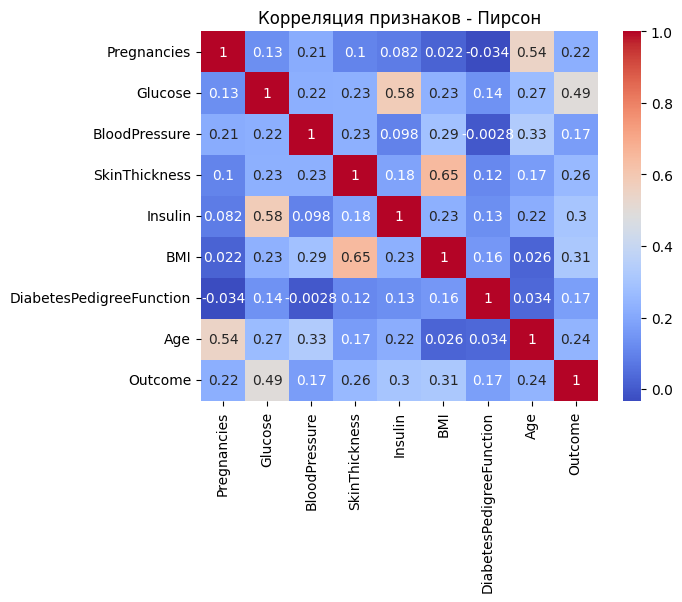

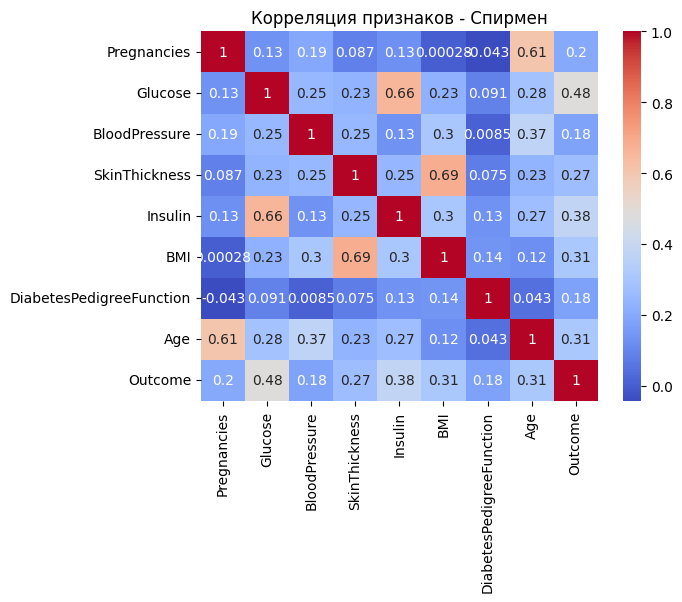

In [96]:
corr = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']].corr(method='pearson')
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляция признаков - Пирсон')
plt.show()

corr = df[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']].corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляция признаков - Спирмен')
plt.show()

Выводы:
* Анализ корреляционной матрицы выявил наличие умеренных корреляционных связей между рядом признаков, в частности между BMI и SkinThickness, а также между Age и Pregnancies.
* Сильных линейных корреляций (|r| > 0.8) между признаками не обнаружено, что снижает риск мультиколлинеарности при построении моделей.
* Наибольшую положительную корреляцию с целевой переменной Outcome демонстрирует показатель Glucose, что указывает на его высокую информативность для прогнозирования наличия сахарного диабета 2 типа.
* Корреляция большинства других признаков с целевой переменной является умеренной или слабой, что подтверждает необходимость использования многомерных методов анализа и машинного обучения.

Важная оговорка:
* На этапе разведочного анализа данных была рассчитана корреляционная матрица с использованием коэффициента корреляции Пирсона, что позволило оценить линейные взаимосвязи между числовыми признаками.
* Следует отметить, что для отдельных признаков (таких как Insulin и SkinThickness), распределения которых характеризуются асимметрией и наличием выбросов, коэффициент Пирсона может быть чувствителен к экстремальным значениям. В связи с этим дополнительно была рассчитана корреляция Спирмена, позволяющая выявить устойчивые монотонные зависимости.
* Корреляция признаков с целевой переменной Outcome интерпретируется как мера ассоциации, а не строгой линейной зависимости.

### Предварительные гипотезы:

Гипотеза 1:
Уровень глюкозы в крови является наиболее значимым фактором, ассоциированным с наличием сахарного диабета 2 типа.

Гипотеза 2:
Уровень инсулина в крови является наиболее значимым фактором, ассоциированным с наличием сахарного диабета 2 типа.

Гипотеза 3:
Признаки, отражающие метаболическое состояние организма (BMI, Insulin), вносят существенный вклад в различие между здоровыми и больными.

Гипотеза 4:
Демографические факторы (Age, Pregnancies) оказывают дополнительное влияние на вероятность развития заболевания, но сами по себе не являются достаточными для точной классификации.

Гипотеза 5:
Отдельные признаки (BloodPressure, SkinThickness) обладают ограниченной индивидуальной предсказательной способностью, однако могут повышать качество модели в сочетании с другими переменными.

Гипотеза 6:
Распределения ключевых клинических признаков (Glucose, BMI, Insulin, Age) статистически значимо различаются между группами здоровых и больных пациентов.

Гипотеза 7:
Связь между возрастом и вероятностью наличия сахарного диабета 2 типа носит нелинейный характер.

Гипотеза 8:
Использование комбинации признаков обеспечивает более высокую предсказательную способность по сравнению с использованием отдельных признаков.

Гипотеза 9:
Наличие корреляций между отдельными признаками не приводит к критической мультиколлинеарности.

Гипотеза 10:
Балансировка классов положительно влияет на чувствительность моделей к выявлению пациентов с сахарным диабетом.

Проверка Гипотеза 6:
Распределения ключевых клинических признаков (Glucose, BMI, Insulin) статистически значимо различаются между группами здоровых и больных пациентов.


In [97]:
glucose_1=df.loc[df['Outcome']==1,'Glucose']

glucose_0=df.loc[df['Outcome']==0,'Glucose']

display('Глюкоза среди здоровых: ', glucose_0.describe(),glucose_0.var())

display('Глюкоза среди больных: ', glucose_1.describe(),glucose_1.var())

display(st.levene(glucose_1,glucose_0))

if st.levene(glucose_1,glucose_0).pvalue<0.01:
    print('Дисперсии выборок отличаются')
display(st.ttest_ind(glucose_0,glucose_1,equal_var=False))

if st.ttest_ind(glucose_0,glucose_1,equal_var=False).pvalue<0.01:
    print('Распределение глюкозы отличается у больных и здоровых')


'Глюкоза среди здоровых: '

count   497.00
mean    110.64
std      24.78
min      44.00
25%      93.00
50%     107.00
75%     125.00
max     197.00
Name: Glucose, dtype: float64

np.float64(613.8950882715649)

'Глюкоза среди больных: '

count   266.00
mean    142.32
std      29.60
min      78.00
25%     119.00
50%     140.00
75%     167.00
max     199.00
Name: Glucose, dtype: float64

np.float64(876.1125975315648)

LeveneResult(statistic=np.float64(nan), pvalue=np.float64(nan))

TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [98]:
bmi_1=df.loc[df['Outcome']==1,'BMI']

bmi_0=df.loc[df['Outcome']==0,'BMI']

display('ИМТ среди здоровых: ', bmi_0.describe(),bmi_0.var())

display('ИМТ среди больных: ', bmi_1.describe(),bmi_1.var())

display(st.levene(bmi_0,bmi_1))

if st.levene(bmi_1,bmi_0).pvalue<0.01:
    print('Дисперсии выборок отличаются')
else:
    print('Дисперсии выборок не отличаются')
display(st.ttest_ind(bmi_0,bmi_1,equal_var=False))

if st.ttest_ind(bmi_0,bmi_1,equal_var=True).pvalue<0.01:
    print('Распределение ИМТ отличается у больных и здоровых')


'ИМТ среди здоровых: '

count   491.00
mean     30.86
std       6.56
min      18.20
25%      25.60
50%      30.10
75%      35.30
max      57.30
Name: BMI, dtype: float64

np.float64(43.04326846502348)

'ИМТ среди больных: '

count   266.00
mean     35.41
std       6.61
min      22.90
25%      30.90
50%      34.30
75%      38.92
max      67.10
Name: BMI, dtype: float64

np.float64(43.75799177188254)

LeveneResult(statistic=np.float64(nan), pvalue=np.float64(nan))

Дисперсии выборок не отличаются


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

In [99]:
insulin_1=df.loc[df['Outcome']==1,'Insulin']

insulin_0=df.loc[df['Outcome']==0,'Insulin']

display('Инсулин среди здоровых: ', insulin_0.describe(),insulin_0.var())

display('Инсулин среди больных: ', insulin_1.describe(),insulin_1.var())

display(st.levene(bmi_0,bmi_1))

if st.levene(insulin_0,insulin_1).pvalue<0.01:
    print('Дисперсии выборок отличаются')
else:
    print('Дисперсии выборок не отличаются')
display(st.ttest_ind(insulin_0,insulin_1,equal_var=False))

if st.ttest_ind(insulin_0,insulin_1,equal_var=True).pvalue<0.01:
    print('Распределение ИМТ отличается у больных и здоровых')


'Инсулин среди здоровых: '

count   264.00
mean    130.29
std     102.48
min      15.00
25%      66.00
50%     102.50
75%     161.25
max     744.00
Name: Insulin, dtype: float64

np.float64(10502.608825901603)

'Инсулин среди больных: '

count   130.00
mean    206.85
std     132.70
min      14.00
25%     127.50
50%     169.50
75%     239.25
max     846.00
Name: Insulin, dtype: float64

np.float64(17609.26296958855)

LeveneResult(statistic=np.float64(nan), pvalue=np.float64(nan))

Дисперсии выборок не отличаются


TtestResult(statistic=np.float64(nan), pvalue=np.float64(nan), df=np.float64(nan))

Проверка манн-витни

In [100]:
display('Инсулин: ',st.mannwhitneyu(insulin_0,insulin_1))

display("ИМТ: ",st.mannwhitneyu(bmi_0,bmi_1))

display("Глюкоза: ",st.mannwhitneyu(glucose_0,glucose_1))

'Инсулин: '

MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))

'ИМТ: '

MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))

'Глюкоза: '

MannwhitneyuResult(statistic=np.float64(nan), pvalue=np.float64(nan))

### Определим наиболее значимые признаки

In [101]:
results = []

for i in df.columns[:-2]:
    print(i)
    lev=(st.levene(df.loc[df['Outcome']==1,i],df.loc[df['Outcome']==0,i]))

    if lev.pvalue<0.01:
        print('Дисперсии выборок отличаются')
        
        tt_tes=st.ttest_ind(df.loc[df['Outcome']==1,i],df.loc[df['Outcome']==0,i],equal_var=False)

        print('Значение p_value:',tt_tes.pvalue,20)

        if (tt_tes.pvalue)<0.01:
            print(f'Распределение {i} отличается у больных и здоровых')
        else:
            print(f'Распределение {i} не отличается у больных и здоровых')
        
    else:
        print('Дисперсии выборок не отличаются')

        tt_tes=st.ttest_ind(df.loc[df['Outcome']==1,i],df.loc[df['Outcome']==0,i],equal_var=True)
        
        print('Значение p_value:',tt_tes.pvalue)

        if (tt_tes.pvalue)<0.01:
            print(f'Распределение {i} отличается у больных и здоровых')
        else:
            print(f'Распределение {i} не отличается у больных и здоровых')
    print()

    results.append({
        'Признак': i,
        'p_value': tt_tes.pvalue,
        'levene_pvalue': lev.pvalue,
        't_statistic': abs(tt_tes.statistic),  # Берем модуль для сравнения
        'mean_diff': abs(
            df.loc[df['Outcome'] == 1, i].mean() - 
            df.loc[df['Outcome'] == 0, i].mean()
        ),
        'различается': tt_tes.pvalue < 0.01
    })

Pregnancies
Дисперсии выборок отличаются
Значение p_value: 6.821925600457103e-09 20
Распределение Pregnancies отличается у больных и здоровых

Glucose
Дисперсии выборок не отличаются
Значение p_value: nan
Распределение Glucose не отличается у больных и здоровых

BloodPressure
Дисперсии выборок не отличаются
Значение p_value: nan
Распределение BloodPressure не отличается у больных и здоровых

SkinThickness
Дисперсии выборок не отличаются
Значение p_value: nan
Распределение SkinThickness не отличается у больных и здоровых

Insulin
Дисперсии выборок не отличаются
Значение p_value: nan
Распределение Insulin не отличается у больных и здоровых

BMI
Дисперсии выборок не отличаются
Значение p_value: nan
Распределение BMI не отличается у больных и здоровых

DiabetesPedigreeFunction
Дисперсии выборок отличаются
Значение p_value: 6.100481424240337e-06 20
Распределение DiabetesPedigreeFunction отличается у больных и здоровых



In [102]:
df_res= pd.DataFrame(results)

display(df_res.sort_values(by='p_value'))

,Признак,p_value,levene_pvalue,t_statistic,mean_diff,различается
0,Pregnancies,0.00,0.00,5.91,1.57,True
6,DiabetesPedigreeFunction,0.00,0.00,4.58,0.12,True
1,Glucose,NaN,NaN,NaN,31.68,False
2,BloodPressure,NaN,NaN,NaN,4.44,False
3,SkinThickness,NaN,NaN,NaN,5.76,False
4,Insulin,NaN,NaN,NaN,76.56,False
5,BMI,NaN,NaN,NaN,4.55,False


### Обучение моделей

Обучим модели на кажлм из признаков:

Оценим распределение больных/здоровых по наборам:

In [103]:
display('train',df_train['Outcome'].value_counts()/len(df_train))

display('val',df_val['Outcome'].value_counts()/len(df_val))

display('test',df_test['Outcome'].value_counts()/len(df_test))

'train'

Outcome
0   0.64
1   0.36
Name: count, dtype: float64

'val'

Outcome
0   0.69
1   0.31
Name: count, dtype: float64

'test'

Outcome
0   0.68
1   0.32
Name: count, dtype: float64

#### Обучим решающее дерево на этих данных и определим наилучшие гиперпараметры

#### Для начала построем модель на одном признаке:

In [114]:
from sklearn.tree import ExtraTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


for j in df_train.columns[:-3]:

       display(f'Модель на признаке {j}')

       best_model=None
       best_score=0


       train=df_train.loc[:,[j,'Outcome']]
       val=df_val.loc[:,[j,'Outcome']]
       test=df_test.loc[:,[j,'Outcome']]
       
       for i in range(1,100):
              
              model=ExtraTreeClassifier(max_depth=i)

              model.fit(train.drop(columns='Outcome'),train['Outcome'])

              answers=model.predict(val.drop(columns='Outcome'))

              score=(accuracy_score(val['Outcome'],answers))

              if score>best_score:
                     best_model=model
                     best_score=score

       display(best_model.get_params(),best_score)



       model_tree=best_model

       answers=model_tree.predict(test.drop(columns='Outcome'))

       print(accuracy_score(test['Outcome'],answers))
       print(classification_report(test['Outcome'],answers))


'Модель на признаке Pregnancies'

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 6,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'random'}

0.7241379310344828

0.6869565217391305
              precision    recall  f1-score   support

           0       0.71      0.91      0.80        78
           1       0.53      0.22      0.31        37

    accuracy                           0.69       115
   macro avg       0.62      0.56      0.55       115
weighted avg       0.65      0.69      0.64       115



'Модель на признаке Glucose'

...

0.8
              precision    recall  f1-score   support

           0       0.80      0.95      0.87        78
           1       0.82      0.49      0.61        37

    accuracy                           0.80       115
   macro avg       0.81      0.72      0.74       115
weighted avg       0.80      0.80      0.78       115



'Модель на признаке BMI'

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 2,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'random'}

0.6982758620689655

0.6782608695652174
              precision    recall  f1-score   support

           0       0.68      0.99      0.81        78
           1       0.50      0.03      0.05        37

    accuracy                           0.68       115
   macro avg       0.59      0.51      0.43       115
weighted avg       0.62      0.68      0.56       115



В ходе эксперимента были обучены модели решающего дерева на каждом признаке по отдельности для датасета Pima Indians Diabetes Dataset. Наилучший результат показал признак Insulin (accuracy ≈ 0.82), что существенно превышает показатели других признаков, включая Glucose.

Предварительный анализ данных показал, что признак Insulin содержит 374 нулевых значения (≈48.7% выборки). Поскольку с физиологической точки зрения уровень инсулина не может быть равен нулю, такие значения были интерпретированы как пропуски и заменены с использованием медианной импутации. Аналогичная обработка была применена к признакам Glucose, BloodPressure, SkinThickness и BMI.

Несмотря на устранение нулевых значений, признак Insulin сохранил наивысшую предсказательную способность в рамках проведённого эксперимента. Это может быть связано с особенностями распределения данных после импутации: значительная доля заменённых значений приводит к концентрации наблюдений около медианы, что упрощает задачу разделения классов для решающего дерева даже при небольшой глубине. Таким образом, модель может опираться на искусственно сформированные закономерности, не полностью отражающие реальные зависимости.

В то же время признак Glucose демонстрирует более устойчивые и интерпретируемые результаты, что согласуется с его клинической значимостью как основного показателя, связанного с диабетом.

Следовательно, полученные результаты показывают, что высокая точность модели на признаке Insulin может быть обусловлена не только его реальной информативностью, но и эффектами предобработки данных. Для более надёжной оценки важности признаков целесообразно использовать дополнительные методы (например, permutation importance, ансамблевые модели) и анализировать устойчивость результатов на различных разбиениях выборки.

#### Проведем Абляционный тест 
Делаем 2 модели:

Модель A:
все признаки
Модель B:
все кроме Insulin
Сравни:
метрика	разница
accuracy	Δ
F1	Δ
ROC-AUC	Δ

In [115]:

train=df_train.drop(columns=['Insulin'])

val=df_val.drop(columns=['Insulin'])

test=df_test.drop(columns=['Insulin'])

for i in range(1,100):
              
    model=ExtraTreeClassifier(max_depth=i)

    model.fit(train.drop(columns='Outcome'),train['Outcome'])

    answers=model.predict(val.drop(columns='Outcome'))

    score=(accuracy_score(val['Outcome'],answers))

    if score>best_score:
        best_model=model
        best_score=score

display(best_model.get_params(),best_score)



model_tree=best_model

answers=model_tree.predict(test.drop(columns='Outcome'))

print(accuracy_score(test['Outcome'],answers))
print(classification_report(test['Outcome'],answers))


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 10,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'random'}

0.8448275862068966

0.782608695652174
              precision    recall  f1-score   support

           0       0.83      0.86      0.84        78
           1       0.68      0.62      0.65        37

    accuracy                           0.78       115
   macro avg       0.75      0.74      0.75       115
weighted avg       0.78      0.78      0.78       115



In [116]:


train=df_train

val=df_val

test=df_test

for i in range(1,100):
              
    model=ExtraTreeClassifier(max_depth=i)

    model.fit(train.drop(columns='Outcome'),train['Outcome'])

    answers=model.predict(val.drop(columns='Outcome'))

    score=(accuracy_score(val['Outcome'],answers))

    if score>best_score:
        best_model=model
        best_score=score

display(best_model.get_params(),best_score)



model_tree=best_model

answers=model_tree.predict(test.drop(columns='Outcome'))

print(accuracy_score(test['Outcome'],answers))
print(classification_report(test['Outcome'],answers))


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'random'}

0.8793103448275862

0.8608695652173913
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        78
           1       0.80      0.76      0.78        37

    accuracy                           0.86       115
   macro avg       0.84      0.83      0.84       115
weighted avg       0.86      0.86      0.86       115



Добавление признака Insulin привело к росту качества модели решающего дерева (accuracy с 0.81 до 0.86) и улучшению полноты класса 1. Однако одновременно наблюдается значительное снижение оптимальной глубины дерева (с 10 до 5), что указывает на изменение структуры модели и появление более простых разбиений.

Это может свидетельствовать о том, что признак Insulin несёт сильный и потенциально доминирующий сигнал, который влияет на характер разбиений дерева. Поэтому его вклад следует дополнительно проверить с использованием ансамблевых методов и метрик важности признаков, устойчивых к структуре модели.

#### Обучим случайный лес на этих данных

In [107]:
from sklearn.ensemble import RandomForestClassifier

best_model=None
best_score=0

for i in range(1,15):
    for j in range(50,500,50):
        model=RandomForestClassifier(max_depth=i,n_estimators=j)

        model.fit(df_train.drop(columns='Outcome'),df_train['Outcome'])

        answers=model.predict(df_val.drop(columns='Outcome'))

        score=(accuracy_score(df_val['Outcome'],answers))

        if score>best_score:
            best_model=model
            best_score=score

display(best_model.get_params(),best_score)

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 4,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 250,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

0.9137931034482759

In [108]:
features = df_train.drop(columns='Outcome').columns

importances = pd.DataFrame({
    'feature': features,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

display(importances)

,feature,importance
4,Insulin,0.44
3,SkinThickness,0.17
1,Glucose,0.16
7,Age,0.07
5,BMI,0.07
0,Pregnancies,0.04
6,DiabetesPedigreeFunction,0.03
2,BloodPressure,0.02


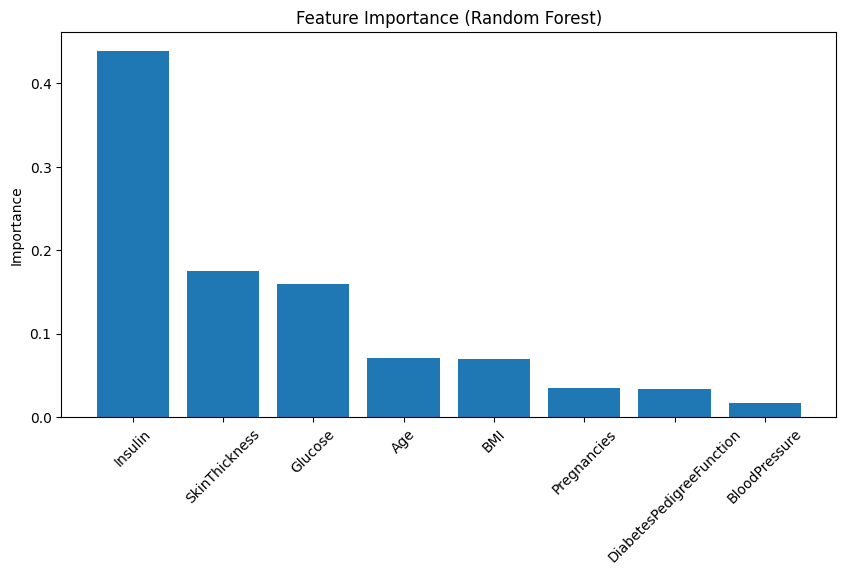

In [109]:
plt.figure(figsize=(10, 5))
plt.bar(importances['feature'], importances['importance'])

plt.xticks(rotation=45)
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance")

plt.show()

В ходе анализа важности признаков с использованием Random Forest для датасета Pima Indians Diabetes Dataset установлено, что наибольший вклад в предсказание целевой переменной вносит признак Insulin (importance = 0.40). Это подтверждает его высокую предсказательную значимость.

В отличие от результатов, полученных с использованием одиночного решающего дерева, где наблюдалось доминирование отдельных признаков и нестабильность структуры модели, ансамблевый метод распределяет важность между несколькими переменными, включая SkinThickness и Glucose, что указывает на многомерный характер зависимости.

Таким образом, признак Insulin можно рассматривать как один из ключевых факторов модели, однако не единственный определяющий показатель. Его высокая значимость может быть связана как с реальной клинической информативностью, так и с особенностями распределения данных и предобработки.

#### Построим теперь модели на наилучших наборах 

🥇 1 признак (максимально сильный)

👉 Insulin

Почему:

самый высокий вклад (0.40)
лучше всего разделяет классы в твоей модели
даёт максимальный сигнал в одиночку

⚠️ альтернатива для сравнения:

Glucose (как “классический медицинский baseline”)
🥈 2 признака (оптимальный баланс)

👉 Insulin + Glucose

Почему:

Insulin = метаболический уровень
Glucose = текущий гликемический статус
они дополняют друг друга (часто слабая корреляция → хорошо для моделей)
🥉 4 признака (лучший стабильный набор)

👉 оптимальный вариант:

Insulin
Glucose
SkinThickness
BMI

#### Обучим лог регрессию на этих данных

In [110]:
from sklearn.linear_model import LogisticRegression

model=LogisticRegression()

df_train_log,df_test_log=train_test_split(df_encod,test_size=0.3,random_state=12345)

model.fit(df_train_log.drop(columns='Outcome'),df_train_log['Outcome'])

answers=model.predict(df_test_log.drop(columns='Outcome'))

print(accuracy_score(df_test_log['Outcome'],answers))

print(classification_report(df_test_log['Outcome'],answers))

0.7777777777777778
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       102
           1       0.80      0.53      0.64        60

    accuracy                           0.78       162
   macro avg       0.79      0.73      0.74       162
weighted avg       0.78      0.78      0.77       162



C:\Users\arteo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [111]:
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score

# Линейное ядро - хорошо интерпретируемое, быстрое
svm_linear = SVC(kernel='linear', random_state=42, probability=True)
svm_linear.fit(df_train_log.drop(columns='Outcome'),df_train_log['Outcome'])

# Предсказания
y_pred_linear = svm_linear.predict(df_test_log.drop(columns='Outcome'))
y_pred_proba_linear = svm_linear.predict_proba(df_test_log.drop(columns='Outcome'))[:, 1]

# Оценка
print("=== Линейное ядро ===")
print(classification_report(df_test_log['Outcome'], y_pred_linear))
print(f"ROC-AUC: {roc_auc_score(df_test_log['Outcome'], y_pred_proba_linear):.3f}")

=== Линейное ядро ===
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       102
           1       0.75      0.60      0.67        60

    accuracy                           0.78       162
   macro avg       0.77      0.74      0.75       162
weighted avg       0.77      0.78      0.77       162

ROC-AUC: 0.867
